In [1]:
import os, sys, json, math, random, time
from pathlib import Path
from typing import Optional, Dict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

# Metrics: if torchmetrics isn't available, we degrade gracefully
try:
    from torchmetrics.classification import MulticlassF1Score, MulticlassAccuracy, MulticlassConfusionMatrix
    TORCHMETRICS_OK = True
except Exception as e:
    TORCHMETRICS_OK = False
    print("torchmetrics not available; will fallback to manual metrics for accuracy.")

In [2]:
# Optional: timm has many pretrained backbones (including ViT variants)
try:
    import timm
    TIMM_OK = True
except Exception as e:
    TIMM_OK = False
    print("timm not available; will fallback to torchvision ViT if present.")

In [3]:
# Focal Loss
# A robust alternative to CrossEntropy for imbalanced datasets.
# It down-weights easy examples and focuses on hard ones.
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight     # class weights (Tensor) or None
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')  # compute per-sample CE
    def forward(self, logits, target):
        ce = self.ce(logits, target)    # basic CE loss for each item
        pt = torch.exp(-ce)             # convert loss to prob-like term
        loss = (1-pt)**self.gamma * ce  # focal scaling
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

def set_seed(seed=42):
    """Set seeds and opt into performance-friendly cudnn mode."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    # We allow benchmark for speed; determinism is relaxed for throughput.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [4]:
# Configuration
CSV_PATH = "../osv-5m_subset/train_subset.csv"   
IMAGE_ROOT = "../osv-5m_subset/train"  

# Output folder where checkpoints and logs will be saved
OUTPUT_DIR = "./outputs/country_cls"

# Image & training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
NUM_WORKERS = 4

# Imbalance + training strategy
USE_FOCAL = False          # True -> FocalLoss, False -> CrossEntropy with label smoothing
LABEL_SMOOTH = 0.1
LINEAR_PROBE_ONLY = True   # True -> freeze backbone, train only the classification head (fast baseline)

# Optimizer & schedule
HEAD_LR = 3e-4             # LR used when only head is trained
BACKBONE_LR = 1e-5         # LR for full/partial fine-tuning
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 3          # warmup length for cosine LR

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Will save to:", Path(OUTPUT_DIR).resolve())


Will save to: /work/cssema416/202610/28/Classifier/outputs/country_cls


In [5]:
# Read CSV, detect columns, and build label map
df = pd.read_csv(CSV_PATH)
print("CSV columns:", df.columns.tolist())
display(df.head())

# Heuristics to find the likely image path column
img_col_candidates = [c for c in df.columns if c.lower() in [
    "image_path","path","filepath","image","img","filename","file"
]]
# The country column should be easy to spot
country_col_candidates = [c for c in df.columns if c.lower() in [
    "country","label","country_code","y","target"
]]

assert len(country_col_candidates) >= 1, "Could not find a 'country' label column. Rename to 'country' or update code."
# If no explicit image column, some datasets store only an id; we fallback to 'id' and expect you to customize join logic if needed.
if len(img_col_candidates)==0 and 'id' in df.columns:
    img_col_candidates = ['id']

IMG_COL = img_col_candidates[0] if img_col_candidates else None
COUNTRY_COL = country_col_candidates[0]
print("Detected IMG_COL:", IMG_COL, "| COUNTRY_COL:", COUNTRY_COL)

def build_image_path(row):
    """
    Converts whatever is in the image column into an absolute/valid path.
    - If it's already absolute, we return it as-is.
    - If it's relative or a basename, we join with IMAGE_ROOT.
    """
    if IMG_COL is None:
        raise ValueError("No image column detected. Please set IMG_COL manually.")
    p = str(row[IMG_COL])
    if os.path.isabs(p):
        return p
    if IMAGE_ROOT and not os.path.exists(p):
        return str(Path(IMAGE_ROOT) / p)
    return p

# Build mappings between country string labels and integer IDs [0..C-1].
countries = sorted(df[COUNTRY_COL].astype(str).unique().tolist())
ctoi = {c:i for i,c in enumerate(countries)}
itoc = {i:c for c,i in ctoi.items()}
print("Num countries:", len(countries))

# Save label map for later inference
with open(Path(OUTPUT_DIR)/"label_map.json","w") as f:
    json.dump({"ctoi": ctoi, "itoc": itoc}, f, indent=2)


CSV columns: ['id', 'latitude', 'longitude', 'thumb_original_url', 'country', 'sequence', 'captured_at', 'lon_bin', 'lat_bin', 'cell', 'region', 'sub-region', 'city', 'land_cover', 'road_index', 'drive_side', 'climate', 'soil', 'dist_sea', 'quadtree_10_5000', 'quadtree_10_25000', 'quadtree_10_1000', 'quadtree_10_50000', 'quadtree_10_12500', 'quadtree_10_500', 'quadtree_10_2500', 'unique_region', 'unique_sub-region', 'unique_city', 'unique_country', 'creator_username', 'creator_id']


,id,latitude,longitude,thumb_original_url,country,sequence,captured_at,lon_bin,lat_bin,cell,...,quadtree_10_50000,quadtree_10_12500,quadtree_10_500,quadtree_10_2500,unique_region,unique_sub-region,unique_city,unique_country,creator_username,creator_id
0,149569917138458,45.887541,22.451873,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,RO,9l9im94ivovbzy0qwgcpsl,1492440508000,55,74,"(55, 74)",...,205,839,13957,4152,Hunedoara_RO,NaN,Lapugiu de Jos_NaN_Hunedoara_RO,RO,pepenova,1.028911e+14
1,919724982215388,35.245933,140.005689,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,JP,eBS_n33kZpKWulqo48738g,1565936860035,88,66,"(88, 66)",...,190,774,12772,3823,Chiba_JP,NaN,Kimitsu_NaN_Chiba_JP,JP,drivephotograph,1.064098e+14
2,729329481758662,-36.143436,147.002683,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,AU,zeJO5Lj16QZCHb8dtrMNgD,1648998548000,90,13,"(90, 13)",...,34,121,1828,605,New South Wales_AU,Albury Municipality_New South Wales_AU,East Albury_Albury Municipality_New South Wale...,AU,skillsy,1.006477e+14
3,1929474523866300,38.465051,-28.288432,https://scontent-cdg4-1.xx.fbcdn.net/m1/v/t6/A...,PT,VAjsepXiS_iq-Gy-d9QAdQ,1526313450615,41,69,"(41, 69)",...,111,456,7542,2305,Azores_PT,Sao Roque do Pico_Azores_PT,Sao Roque do Pico_Sao Roque do Pico_Azores_PT,PT,ligfietser,1.022241e+14
4,205345274735954,57.304645,25.211512,https://scontent-cdg4-3.xx.fbcdn.net/m1/v/t6/A...,LV,ggxzc4t3d92422taut042v,1596196803683,56,83,"(56, 83)",...,243,987,17000,4955,Cesu Rajons_LV,NaN,Cesis_NaN_Cesu Rajons_LV,LV,karlis,1.100973e+14


Detected IMG_COL: id | COUNTRY_COL: country
Num countries: 169


In [12]:
# ---------- Robust path resolution & prefilter ----------
from pathlib import Path
import os, glob

# Make roots absolute to avoid surprises with relative .. paths
CSV_PATH = str(Path(CSV_PATH).resolve())
IMAGE_ROOT = str(Path(IMAGE_ROOT).resolve())
print("CSV_PATH:", CSV_PATH)
print("IMAGE_ROOT:", IMAGE_ROOT)

# Common extensions (lower + upper just in case)
EXTS = [".jpg", ".jpeg", ".png", ".webp", ".bmp"]
EXTS = EXTS + [e.upper() for e in EXTS]

def resolve_image_path(row, image_root=IMAGE_ROOT):
    """Return an existing file path for this row's image, or None if not found."""
    raw = str(row[IMG_COL]) if IMG_COL is not None else ""
    if not raw:
        return None

    # If CSV already stores absolute paths
    if os.path.isabs(raw) and os.path.isfile(raw):
        return raw

    # If CSV stores a relative path with extension (e.g., "abc/123.jpg")
    candidate = os.path.join(image_root, raw)
    if os.path.isfile(candidate):
        return candidate

    # If CSV stores a bare stem or id without extension (e.g., "369522271131412")
    stem = Path(raw).stem  # strip any accidental extension
    # Try common extensions in the root
    for ext in EXTS:
        c2 = os.path.join(image_root, stem + ext)
        if os.path.isfile(c2):
            return c2

    # Try searching subfolders (glob). This is slower, so we do it last.
    # 1) Exact stem + any ext
    for ext in EXTS:
        hits = glob.glob(os.path.join(image_root, "**", stem + ext), recursive=True)
        if hits:
            return hits[0]

    # 2) Stem as prefix (some datasets add suffixes)
    hits = glob.glob(os.path.join(image_root, "**", stem + ".*"), recursive=True)
    # Prefer known image extensions if many hits
    if hits:
        # reorder so known image types come first
        hits_sorted = sorted(hits, key=lambda p: (Path(p).suffix.lower() not in [e.lower() for e in EXTS], len(p)))
        return hits_sorted[0]

    return None

# Build resolved paths
df["resolved_path"] = df.apply(resolve_image_path, axis=1)

# Prefilter rows that couldn't be resolved to a real file
missing = df["resolved_path"].isna().sum()
if missing > 0:
    print(f"⚠️  Could not resolve {missing} / {len(df)} image paths. Dropping missing rows from training/val.")
df = df[~df["resolved_path"].isna()].reset_index(drop=True)

# Switch dataset to use the resolved path column
IMG_COL = "resolved_path"
print("Using IMG_COL =", IMG_COL, " | Total images after filter:", len(df))

# Optional: sanity check a few rows
display(df[[IMG_COL, COUNTRY_COL]].head())


CSV_PATH: /work/cssema416/202610/28/osv-5m_subset/train_subset.csv
IMAGE_ROOT: /work/cssema416/202610/28/osv-5m_subset/train
Using IMG_COL = resolved_path  | Total images after filter: 10000


,resolved_path,country
0,/work/cssema416/202610/28/osv-5m_subset/train/...,RO
1,/work/cssema416/202610/28/osv-5m_subset/train/...,JP
2,/work/cssema416/202610/28/osv-5m_subset/train/...,AU
3,/work/cssema416/202610/28/osv-5m_subset/train/...,PT
4,/work/cssema416/202610/28/osv-5m_subset/train/...,LV


In [13]:
# Dataset & transforms
def make_transforms(img_size=224, eval=False):
    if eval:
        return transforms.Compose([
            transforms.Resize(int(img_size*1.14)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    return transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.2,0.1),
        transforms.RandomGrayscale(p=0.2),
        transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

class CountryDataset(Dataset):
    """
    Basic dataset that:
    - Loads an image from disk
    - Applies the provided transform
    - Returns (tensor_image, country_id, path)
    """
    def __init__(self, frame: pd.DataFrame, img_col: str, country_col: str, tfm):
        self.df = frame.reset_index(drop=True)
        self.img_col = img_col
        self.country_col = country_col
        self.tfm = tfm
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = build_image_path(row)
        img = Image.open(path).convert("RGB")
        x = self.tfm(img)
        y = ctoi[str(row[self.country_col])]
        return x, y, path


In [14]:
# Robust split & DataLoaders (handles singletons)
from collections import defaultdict
import numpy as np
import random

random.seed(42)
np.random.seed(42)

TEST_FRACTION = 0.10  # 10% val

labels_str = df[COUNTRY_COL].astype(str)
counts = labels_str.value_counts()

# Split dataframe into:
# - df_many: classes with >=2 samples (we can put at least 1 in val)
# - df_single: classes with only 1 sample (keep entirely in train)
df_many   = df[labels_str.map(counts) >= 2].reset_index(drop=True)
df_single = df[labels_str.map(counts) == 1].reset_index(drop=True)

train_indices = []
val_indices   = []

# Per-class manual split for df_many
grouped = df_many.groupby(COUNTRY_COL).groups  # dict: label -> row indices (in df_many)
for label, idxs in grouped.items():
    idxs = list(idxs)
    n = len(idxs)
    # choose at least 1 example for val, but leave at least 1 for train
    n_val = max(1, int(round(n * TEST_FRACTION)))
    if n - n_val < 1:
        n_val = n - 1
    # sample val indices
    val_choice = np.random.choice(idxs, size=n_val, replace=False)
    train_choice = [i for i in idxs if i not in set(val_choice)]
    val_indices.extend(val_choice)
    train_indices.extend(train_choice)

# All singletons -> train only
train_singleton_indices = list(range(len(df_single)))

# Build final train/val DataFrames by concatenating df_many splits with df_single (train only)
train_df = pd.concat(
    [df_many.iloc[train_indices].reset_index(drop=True),
     df_single.iloc[train_singleton_indices].reset_index(drop=True)],
    axis=0, ignore_index=True
)
val_df = df_many.iloc[val_indices].reset_index(drop=True)

print("Singleton classes kept in TRAIN only:", (counts==1).sum())
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Classes total: {len(countries)}")

# Datasets & Loaders
train_ds = CountryDataset(train_df, IMG_COL, COUNTRY_COL, make_transforms(IMG_SIZE, eval=False))
val_ds   = CountryDataset(val_df,   IMG_COL, COUNTRY_COL, make_transforms(IMG_SIZE, eval=True))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Singleton classes kept in TRAIN only: 25
Train: 8972 | Val: 1028 | Classes total: 169


In [15]:
# Build model (offline-safe: no downloading)
def build_model(num_classes: int, pretrained=False, local_checkpoint: str = None):
    """
    pretrained=False  -> never tries to download.
    local_checkpoint  -> path to a .pth/.pt/.safetensors you already have on disk (optional).
    """
    if TIMM_OK:
        # timm path (no download)
        model = timm.create_model('vit_base_patch16_224', pretrained=False)  # keep False
        emb_dim = model.get_classifier().in_features
        model.reset_classifier(num_classes)
        if local_checkpoint and Path(local_checkpoint).exists():
            print(f"Loading local checkpoint: {local_checkpoint}")
            sd = torch.load(local_checkpoint, map_location='cpu')
            # If it's a plain state_dict
            if isinstance(sd, dict) and 'state_dict' in sd:
                sd = sd['state_dict']
            missing, unexpected = model.load_state_dict(sd, strict=False)
            print("Missing:", missing, "Unexpected:", unexpected)
        return model, emb_dim
    else:
        # torchvision fallback (no download)
        from torchvision.models.vision_transformer import vit_b_16
        m = vit_b_16(weights=None)  # <- important: None prevents download
        emb_dim = m.heads.head.in_features
        m.heads.head = nn.Linear(emb_dim, num_classes)
        if local_checkpoint and Path(local_checkpoint).exists():
            print(f"Loading local checkpoint: {local_checkpoint}")
            sd = torch.load(local_checkpoint, map_location='cpu')
            if isinstance(sd, dict) and 'state_dict' in sd:
                sd = sd['state_dict']
            missing, unexpected = m.load_state_dict(sd, strict=False)
            print("Missing:", missing, "Unexpected:", unexpected)
        return m, emb_dim

num_classes = len(countries)
# If you have a local weights file, put its path here; else leave None
LOCAL_VIT_CKPT = None  # e.g., "weights/vit_base_patch16_224_in1k.pth"
model, EMB = build_model(num_classes, pretrained=False, local_checkpoint=LOCAL_VIT_CKPT)
model = model.to(device)

# Linear-probe option stays the same:
if LINEAR_PROBE_ONLY:
    head_params = []
    if TIMM_OK and hasattr(model, 'get_classifier'):
        for p in model.parameters(): p.requires_grad = False
        head = model.get_classifier()
        for p in head.parameters(): p.requires_grad = True
        head_params = list(head.parameters())
    else:
        for name, p in model.named_parameters():
            if 'heads.head' in name:
                p.requires_grad = True
            else:
                p.requires_grad = False
        head_params = [p for n,p in model.named_parameters() if 'heads.head' in n]
else:
    head_params = list(model.parameters())

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable params: 129961


In [16]:
# Loss, optimizer, and cosine LR schedule
# Class weights combat imbalance. We use 1/sqrt(freq) to moderate extremes.
counts = train_df[COUNTRY_COL].astype(str).value_counts()
weights = torch.tensor([1.0/np.sqrt(counts.get(c,1)) for c in countries], dtype=torch.float32).to(device)

# Choose between CrossEntropy (with label smoothing) and Focal Loss
if USE_FOCAL:
    criterion = FocalLoss(gamma=2.0, weight=weights, reduction='mean')
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH, weight=weights)

# Optimizer: head-only (linear probe) or all trainable params
params = head_params if LINEAR_PROBE_ONLY else [p for p in model.parameters() if p.requires_grad]
base_lr = HEAD_LR if LINEAR_PROBE_ONLY else BACKBONE_LR
optimizer = torch.optim.AdamW(params, lr=base_lr, weight_decay=WEIGHT_DECAY)

def cosine_lr(step, total_steps, base_lr, final_lr=1e-6, warmup_steps=0):
    """
    Cosine decay with linear warmup.
    - Returns the LR for the *current step*.
    """
    if step < warmup_steps:
        return base_lr * (step+1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return final_lr + 0.5*(base_lr - final_lr)*(1 + math.cos(math.pi*progress))


In [17]:
# Training and validation loops (with TQDM status bars)
def train_one_epoch(epoch):
    model.train()
    pbar = tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [train]", leave=False)
    running_loss = 0.0
    total, correct = 0, 0
    for xb, yb, _ in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

        # Step-wise LR using cosine schedule + warmup
        step = epoch * len(train_loader) + pbar.n
        lr = cosine_lr(step, EPOCHS*len(train_loader), base_lr=base_lr, warmup_steps=WARMUP_EPOCHS*len(train_loader))
        for g in optimizer.param_groups: g['lr'] = lr

        # Forward/backward/update
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        # Running stats for the status bar
        running_loss += loss.item() * xb.size(0)
        total += yb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred==yb).sum().item()

        pbar.set_postfix(loss=f"{running_loss/max(1,total):.4f}", acc=f"{(correct/max(1,total))*100:.2f}%")
        pbar.update(1)
    pbar.close()
    return running_loss/total, correct/total

@torch.no_grad()
def validate(epoch):
    model.eval()
    pbar = tqdm(total=len(val_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [valid]", leave=False)
    running_loss = 0.0
    total, correct = 0, 0

    # If torchmetrics exists, compute macro metrics as well
    if TORCHMETRICS_OK:
        acc1 = MulticlassAccuracy(num_classes=num_classes, average='macro').to(device)
        acc5 = MulticlassAccuracy(num_classes=num_classes, top_k=5, average='macro').to(device)
        f1m  = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)

    for xb, yb, _ in val_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        total += yb.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred==yb).sum().item()

        if TORCHMETRICS_OK:
            acc1.update(logits, yb); acc5.update(logits, yb); f1m.update(logits, yb)

        pbar.set_postfix(loss=f"{running_loss/max(1,total):.4f}", acc=f"{(correct/max(1,total))*100:.2f}%")
        pbar.update(1)
    pbar.close()

    metrics = {
        "loss": running_loss/total,
        "acc": correct/total,
    }
    if TORCHMETRICS_OK:
        metrics.update({
            "acc_macro": acc1.compute().item(),
            "acc5_macro": acc5.compute().item(),
            "f1_macro": f1m.compute().item(),
        })
    return metrics


In [18]:
# Training driver + checkpointing (robust epoch status bar)
# Use the notebook-friendly tqdm if available; otherwise fall back to auto.
try:
    from tqdm.notebook import tqdm  # best in classic Jupyter/JupyterLab
except Exception:
    from tqdm.auto import tqdm      # works in VS Code/terminals too

best_score = -1.0
history = []

epoch_bar = tqdm(
    range(EPOCHS),
    desc="Training epochs",
    total=EPOCHS,
    leave=True,            # keep bar visible after it finishes
    dynamic_ncols=True     # adapt to cell width
)

for e in epoch_bar:
    tr_loss, tr_acc = train_one_epoch(e)
    val_metrics = validate(e)

    # Compute selection metric: prefer macro-F1 if present, else accuracy
    current_score = val_metrics.get('f1_macro', val_metrics['acc'])

    # Update the bar live
    epoch_bar.set_postfix(
        train_loss=f"{tr_loss:.4f}",
        train_acc=f"{tr_acc*100:.2f}%",
        val_loss=f"{val_metrics['loss']:.4f}",
        val_acc=f"{val_metrics['acc']*100:.2f}%",
        val_f1=f"{val_metrics.get('f1_macro', float('nan')):.4f}",
        best=f"{max(best_score, current_score):.4f}"
    )

    # Also print a clean line that doesn't break the bar rendering
    from tqdm import tqdm as _tqdm_text
    _tqdm_text.write(
        f"Epoch {e+1:03d}: "
        f"train_loss={tr_loss:.4f}, train_acc={tr_acc*100:.2f}%, "
        f"val_loss={val_metrics['loss']:.4f}, val_acc={val_metrics['acc']*100:.2f}%"
        + (f", val_f1={val_metrics.get('f1_macro', float('nan')):.4f}" if 'f1_macro' in val_metrics else '')
    )

    # Save best BEFORE updating best_score
    if current_score > best_score:
        ckpt_path = Path(OUTPUT_DIR) / "best.pt"
        torch.save(
            {
                "model": model.state_dict(),
                "label_map": itoc,
                "config": {"img_size": IMG_SIZE, "countries": countries},
            },
            ckpt_path
        )
        _tqdm_text.write(f"✅ Saved best checkpoint to {ckpt_path}")
        best_score = current_score

    # Log history
    history.append({
        "epoch": e + 1,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        **val_metrics
    })

# Save history at the end
pd.DataFrame(history).to_csv(Path(OUTPUT_DIR)/"train_log.csv", index=False)
from tqdm import tqdm as _tqdm_text
_tqdm_text.write("History saved to outputs/country_cls/train_log.csv")


Training epochs:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20 [train]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 1/20 [valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 001: train_loss=7.2098, train_acc=13.31%, val_loss=8.0078, val_acc=23.05%, val_f1=0.0039
✅ Saved best checkpoint to outputs/country_cls/best.pt


Epoch 2/20 [train]:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch 19/20 [valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 019: train_loss=6.7751, train_acc=24.28%, val_loss=7.9419, val_acc=22.86%, val_f1=0.0101


Epoch 20/20 [train]:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 20/20 [valid]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 020: train_loss=6.7709, train_acc=23.75%, val_loss=7.9415, val_acc=22.76%, val_f1=0.0096
History saved to outputs/country_cls/train_log.csv


Confusion matrix:   0%|          | 0/17 [00:00<?, ?it/s]

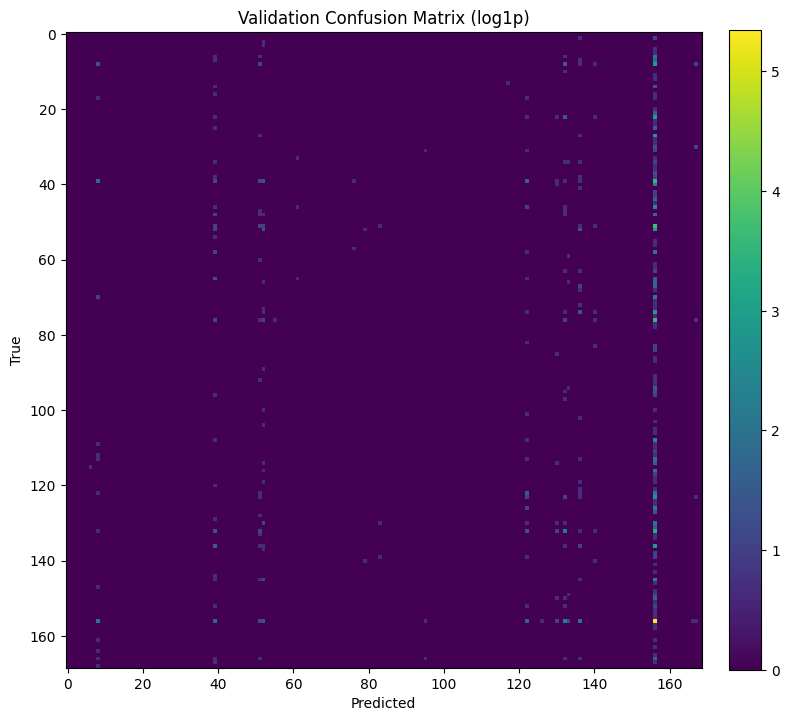

In [19]:
# Confusion Matrix visualization
# We use log1p scale so large classes don't dominate the color range.
@torch.no_grad()
def evaluate_confusion_matrix():
    if not TORCHMETRICS_OK:
        print("torchmetrics not available; skipping confusion matrix.")
        return
    cm_metric = MulticlassConfusionMatrix(num_classes=num_classes).to(device)
    model.eval()
    for xb, yb, _ in tqdm(val_loader, desc="Confusion matrix", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        cm_metric.update(logits, yb)
    cm = cm_metric.compute().cpu().numpy()

    fig, ax = plt.subplots(figsize=(8,8))
    im = ax.imshow(np.log1p(cm))
    ax.set_title("Validation Confusion Matrix (log1p)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

evaluate_confusion_matrix()


In [20]:
# Inference utilities
# Load the best checkpoint and run top-k predictions on arbitrary images.
@torch.no_grad()
def load_best(ckpt_path=Path(OUTPUT_DIR)/"best.pt"):
    ckpt = torch.load(ckpt_path, map_location=device)
    lm = ckpt["label_map"]
    inv_map = {int(k) if isinstance(k,str) and k.isdigit() else int(k) : v for k,v in lm.items()}
    # Rebuild a fresh model with the right number of classes and load weights
    model_eval, _ = build_model(len(inv_map))
    model_eval.load_state_dict(ckpt["model"], strict=False)
    model_eval.eval().to(device)
    return model_eval, inv_map

@torch.no_grad()
def predict_images(paths, img_size=IMG_SIZE, topk=5):
    tfm = make_transforms(img_size, eval=True)
    model_eval, inv_map = load_best()
    results = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        x = tfm(img).unsqueeze(0).to(device)
        logits = model_eval(x)
        prob = logits.softmax(dim=1)
        k = min(topk, prob.shape[1])
        top = torch.topk(prob, k=k, dim=1)
        preds = [(inv_map[idx.item()], prob[0, idx].item()) for idx in top.indices[0]]
        results.append({"path": p, "topk": preds})
    return results

# Example usage:
# samples = ["/absolute/path/to/example.jpg"]
# predict_images(samples)
